# Retail Sales Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data={"Product":["Laptop", "Mouse", "Keyboard", "Laptop", "Mouse","Monitor", "Monitor", "Keyboard", "Laptop", "Mouse"],
      "Quantity":[2, 5, 3, 1, 10, 4, 2, 6, 3, 8],
      "Price":[50000, 500, 1500, 50000, 500, 12000, 12000, 1500, 50000, 500]}
df=pd.DataFrame(data)
df

,Product,Quantity,Price
0,Laptop,2,50000
1,Mouse,5,500
2,Keyboard,3,1500
3,Laptop,1,50000
4,Mouse,10,500
5,Monitor,4,12000
6,Monitor,2,12000
7,Keyboard,6,1500
8,Laptop,3,50000
9,Mouse,8,500


In [3]:
df["Revenue"]=df["Quantity"]*df["Price"]
df

,Product,Quantity,Price,Revenue
0,Laptop,2,50000,100000
1,Mouse,5,500,2500
2,Keyboard,3,1500,4500
3,Laptop,1,50000,50000
4,Mouse,10,500,5000
5,Monitor,4,12000,48000
6,Monitor,2,12000,24000
7,Keyboard,6,1500,9000
8,Laptop,3,50000,150000
9,Mouse,8,500,4000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Product   10 non-null     str  
 1   Quantity  10 non-null     int64
 2   Price     10 non-null     int64
 3   Revenue   10 non-null     int64
dtypes: int64(3), str(1)
memory usage: 452.0 bytes


## Revenue Analysis

In [5]:
df.describe()

,Quantity,Price,Revenue
count,10.000000,10.00000,10.000000
mean,4.400000,17850.00000,39700.000000
std,2.875181,22625.02302,49741.107525
min,1.000000,500.00000,2500.000000
25%,2.250000,750.00000,4625.000000
50%,3.500000,6750.00000,16500.000000
75%,5.750000,40500.00000,49500.000000
max,10.000000,50000.00000,150000.000000


In [6]:
total_revenue=df["Revenue"].sum()
print("Total Revenue :",total_revenue)

Total Revenue : 397000


In [7]:
df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

Product
Laptop      300000
Monitor      72000
Keyboard     13500
Mouse        11500
Name: Revenue, dtype: int64

In [8]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

Product
Mouse       23
Keyboard     9
Laptop       6
Monitor      6
Name: Quantity, dtype: int64

In [9]:
df.groupby("Product")["Revenue"].sum().idxmax()

'Laptop'

In [10]:
df.groupby("Product")["Quantity"].sum().idxmax()

'Mouse'

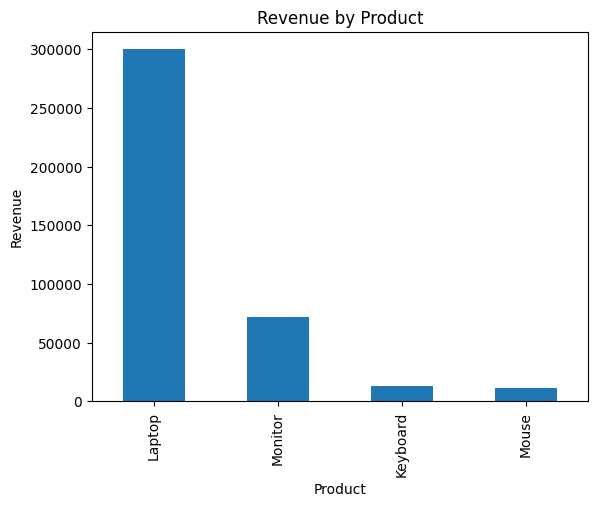

In [11]:
df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

##Loading Data from CSV

In [12]:
sales_df = pd.read_csv("data/sales_data.csv")
sales_df

,Product,Quantity,Price
0,Laptop,2,50000
1,Mouse,5,500
2,Keyboard,3,1500
3,Laptop,1,50000
4,Mouse,10,500
5,Monitor,4,12000
6,Monitor,2,12000
7,Keyboard,6,1500
8,Laptop,3,50000
9,Mouse,8,500


In [13]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Product   10 non-null     str  
 1   Quantity  10 non-null     int64
 2   Price     10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [14]:
sales_df["Revenue"]=sales_df["Quantity"]*sales_df["Price"]
sales_df

,Product,Quantity,Price,Revenue
0,Laptop,2,50000,100000
1,Mouse,5,500,2500
2,Keyboard,3,1500,4500
3,Laptop,1,50000,50000
4,Mouse,10,500,5000
5,Monitor,4,12000,48000
6,Monitor,2,12000,24000
7,Keyboard,6,1500,9000
8,Laptop,3,50000,150000
9,Mouse,8,500,4000


In [17]:
sales_df["Revenue"].sum()

np.int64(397000)

In [18]:
sales_df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

Product
Laptop      300000
Monitor      72000
Keyboard     13500
Mouse        11500
Name: Revenue, dtype: int64

In [19]:
sales_df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

Product
Mouse       23
Keyboard     9
Laptop       6
Monitor      6
Name: Quantity, dtype: int64

In [20]:
sales_df.groupby("Product")["Revenue"].sum().idxmax()

'Laptop'

In [21]:
sales_df.groupby("Product")["Quantity"].sum().idxmax()

'Mouse'

## Visual Analysis

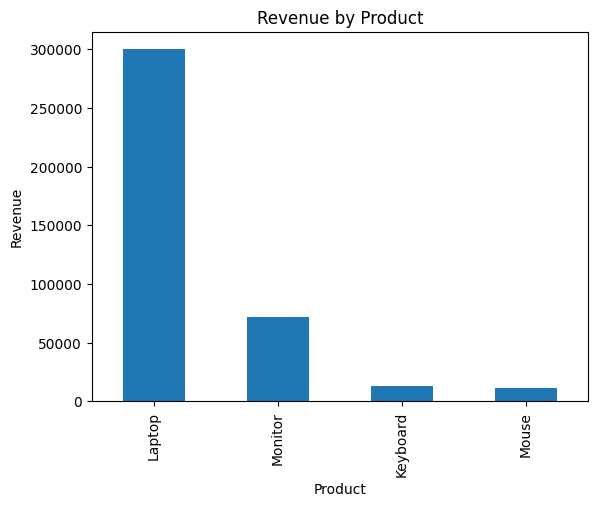

In [22]:
sales_df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

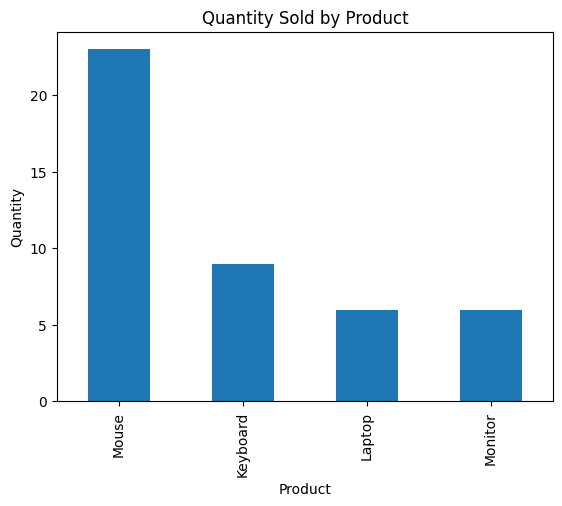

In [23]:
sales_df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

In [25]:
product_revenue = sales_df.groupby("Product")["Revenue"].sum()
(product_revenue / product_revenue.sum()) * 100

Product
Keyboard     3.400504
Laptop      75.566751
Monitor     18.136020
Mouse        2.896725
Name: Revenue, dtype: float64

## KPI Dashboard

In [26]:
total_revenue=sales_df["Revenue"].sum()
top_product=sales_df.groupby("Product")["Revenue"].sum().idxmax()
most_sold=sales_df.groupby("Product")["Quantity"].sum().idxmax()
print("Total Revenue:", total_revenue)
print("Top Revenue Product:", top_product)
print("Most Sold Product:", most_sold)

Total Revenue: 397000
Top Revenue Product: Laptop
Most Sold Product: Mouse


In [28]:
sales_df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(3)

Product
Laptop      300000
Monitor      72000
Keyboard     13500
Name: Revenue, dtype: int64

In [29]:
sales_df.groupby("Product")["Revenue"].mean().sort_values(ascending=False)

Product
Laptop      100000.000000
Monitor      36000.000000
Keyboard      6750.000000
Mouse         3833.333333
Name: Revenue, dtype: float64

## Data Cleaning

In [30]:
messy_data = {"Product": ["Laptop", "Mouse", "Keyboard", "Monitor"],
              "Quantity": [2, None, 3, 4],
              "Price": [50000, 500, None, 12000]}
messy_df = pd.DataFrame(messy_data)
messy_df

,Product,Quantity,Price
0,Laptop,2.0,50000.0
1,Mouse,NaN,500.0
2,Keyboard,3.0,NaN
3,Monitor,4.0,12000.0


In [31]:
messy_df.isnull()

,Product,Quantity,Price
0,False,False,False
1,False,True,False
2,False,False,True
3,False,False,False


In [32]:
messy_df.isnull().sum()

Product     0
Quantity    1
Price       1
dtype: int64

In [33]:
messy_df["Quantity"] = messy_df["Quantity"].fillna(0)
messy_df["Price"] = messy_df["Price"].fillna(messy_df["Price"].mean())
messy_df

,Product,Quantity,Price
0,Laptop,2.0,50000.000000
1,Mouse,0.0,500.000000
2,Keyboard,3.0,20833.333333
3,Monitor,4.0,12000.000000


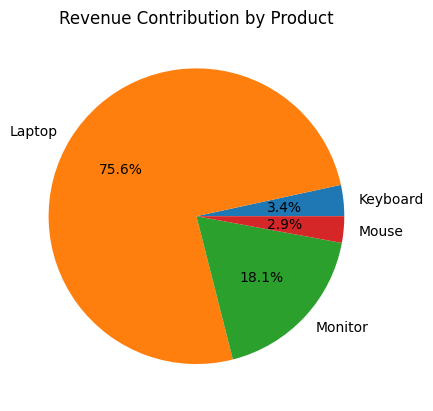

In [35]:
sales_df.groupby("Product")["Revenue"].sum().plot(kind="pie",autopct="%1.1f%%")
plt.title("Revenue Contribution by Product")
plt.ylabel("")
plt.show()

### Business Insights

1. Laptop generated the highest revenue (₹300,000), contributing more than 75% of total sales revenue.

2. Mouse was the most frequently sold product with 23 units sold, indicating strong customer demand.

3. Monitor was the second-highest revenue contributor despite lower sales volume than Mouse.

4. High sales volume does not always lead to high revenue. Mouse sold the most units, but Laptop generated significantly more revenue due to its higher price.

5. Revenue is heavily concentrated in Laptop sales, suggesting that business performance depends strongly on one product category.

6. Product performance varies across revenue and quantity metrics, highlighting the importance of analyzing both sales volume and revenue together.

7. Data cleaning techniques such as identifying and handling missing values improved dataset quality and ensured accurate analysis.

## Conclusion

This project analyzed retail sales data using Pandas and Matplotlib.

Key findings:
- Laptop generated the highest revenue.
- Mouse was the most frequently sold product.
- Revenue was concentrated in high-value products.
- Missing values were identified and handled using data cleaning techniques.

The project demonstrates data loading, cleaning, analysis, visualization, and KPI reporting using Python.